<a href="https://colab.research.google.com/github/shakshi-k/My_projects/blob/Other-fantastic-projects/Delhi_air_quality_k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1)Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


In [2]:
# 2)Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving final_dataset.csv to final_dataset.csv


In [4]:
# 3)Load the dataset
dataset = pd.read_csv("final_dataset.csv")
dataset.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [5]:
dataset.info()
# As there are no null values in the dataset, We do not need to drop anything or take average of anything

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB


In [6]:
dataset.describe()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,15.729637,6.522930,2022.501027,0.189596,4.000684,90.774538,218.219261,37.184921,20.104921,1.025832,36.338871,202.210815
std,8.803105,3.449884,1.118723,0.392116,2.001883,71.650579,129.297734,35.225327,16.543659,0.608305,18.951204,107.801076
min,1.000000,1.000000,2021.000000,0.000000,1.000000,0.050000,9.690000,2.160000,1.210000,0.270000,2.700000,19.000000
25%,8.000000,4.000000,2022.000000,0.000000,2.000000,41.280000,115.110000,17.280000,7.710000,0.610000,24.100000,108.000000
50%,16.000000,7.000000,2023.000000,0.000000,4.000000,72.060000,199.800000,30.490000,15.430000,0.850000,32.470000,189.000000
75%,23.000000,10.000000,2024.000000,0.000000,6.000000,118.500000,297.750000,45.010000,26.620000,1.240000,45.730000,284.000000
max,31.000000,12.000000,2024.000000,1.000000,7.000000,1000.000000,1000.000000,433.980000,113.400000,4.700000,115.870000,500.000000


In [ ]:
# 4)Visualizing the dataset

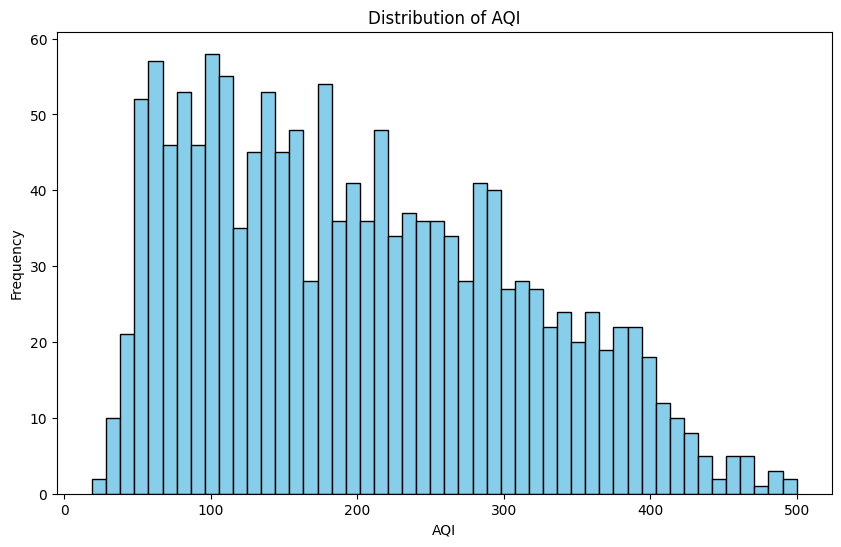

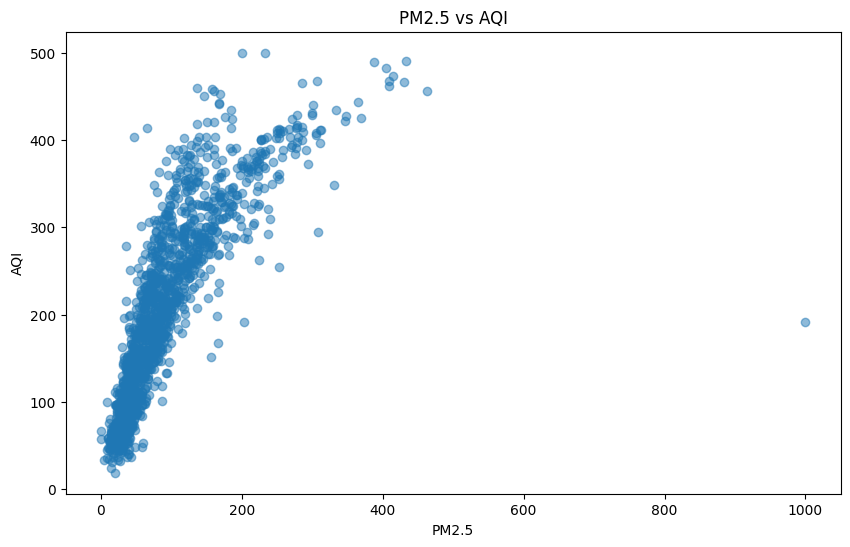

In [8]:
# 4)Visualizing the dataset
# Visualize the distribution of AQI
plt.figure(figsize=(10, 6))
plt.hist(dataset['AQI'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

# Visualize the relationship between PM2.5 and AQI
plt.figure(figsize=(10, 6))
plt.scatter(dataset['PM2.5'], dataset['AQI'], alpha=0.5)
plt.title('PM2.5 vs AQI')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.show()

In [10]:
# Checking the name of the columns
dataset.columns

Index(['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10',
       'NO2', 'SO2', 'CO', 'Ozone', 'AQI'],
      dtype='object')

In [11]:
# As the decision tree classifier is the model I think suited for this dataset we will import the libraries and perform operations
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
# 5) Define Features and labels
x = dataset.drop(columns = ['AQI'])
y = dataset['AQI']
print(x, y)

      Date  Month  Year  Holidays_Count  Days   PM2.5    PM10     NO2    SO2  \
0        1      1  2021               0     5  408.80  442.42  160.61  12.95   
1        2      1  2021               0     6  404.04  561.95   52.85   5.18   
2        3      1  2021               1     7  225.07  239.04  170.95  10.93   
3        4      1  2021               0     1   89.55  132.08  153.98  10.42   
4        5      1  2021               0     2   54.06   55.54  122.66   9.70   
...    ...    ...   ...             ...   ...     ...     ...     ...    ...   
1456    27     12  2024               0     5   58.43  249.17   41.69  65.89   
1457    28     12  2024               0     6   33.83  150.77   33.31  66.14   
1458    29     12  2024               1     7   31.21  139.75   27.01  65.94   
1459    30     12  2024               0     1   38.01  152.83   29.12  65.16   
1460    31     12  2024               0     2   80.42  318.96   40.37  64.98   

        CO  Ozone  
0     2.77  43.19  

In [33]:
# 6) Split the train and test dataset
# stratify is used so that proportion of each class is maintained in both training and testing dataset
#x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, stratify = y, random_state = 42)
#x_train, x_test, y_train, y_test

In [26]:
# 7) Train Decision Tree Classifier
model = DecisionTreeClassifier(criterion= "gini", max_depth=10, random_state=30)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=30)

In [27]:
# 8) predicting the model
y_pred = model.predict(x_test)

In [28]:
# 9) Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
#class_report = classification_report(y_test, y_pred)
#print('Classification Report:\n', class_report)

Accuracy: 0.0034129692832764505


In [37]:
# As there are very few classes in the dataset, stratify doesn't work and it also indicates that the dataset is not suited for decision tree classifier.
# We will try to make another model.
# Let us do K-means on Air quality

In [46]:
# 1) Import the libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

In [39]:
# 2) Scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [49]:
# 3) Elbow Method to Find Optimal k
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

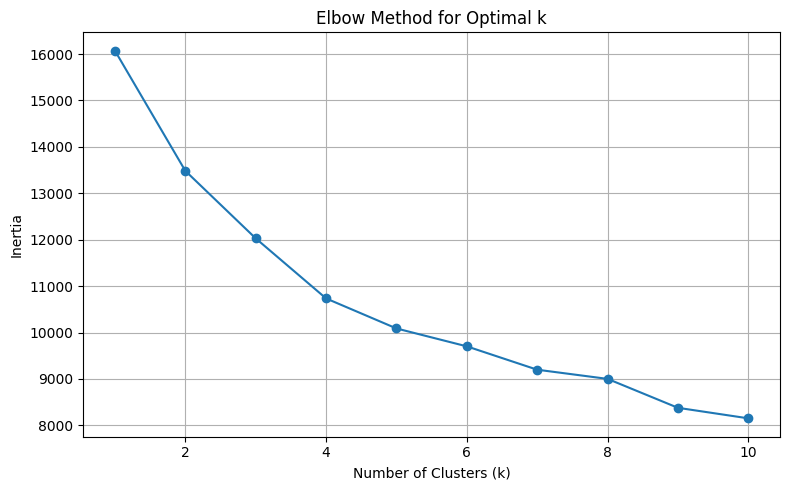

In [50]:
# 4) Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
# 5) Apply K-Means Clustering (using k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
dataset['Cluster'] = kmeans.fit_predict(x_scaled)

In [72]:
# 6) Reduce Dimensions for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)
dataset['PCA1'] = X_pca[:, 0]
dataset['PCA2'] = X_pca[:, 1]

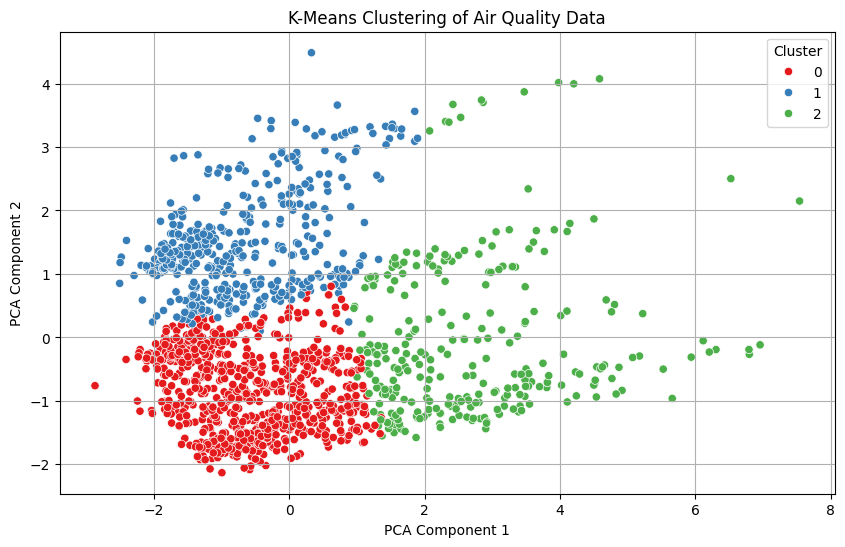

In [73]:
# 7) Plot Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset, x='PCA1', y='PCA2', hue='Cluster', palette='Set1')
plt.title('K-Means Clustering of Air Quality Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

In [74]:
# 8) Cluster Statistics (Mean pollutant levels in each cluster)
pollution_features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
cluster_summary = dataset.groupby('Cluster')[pollution_features + ['AQI']].mean()
print("Cluster-wise average pollutant levels and AQI:\n")
print(cluster_summary)

Cluster-wise average pollutant levels and AQI:

              PM2.5        PM10        NO2        SO2        CO      Ozone  \
Cluster                                                                      
0         64.569297  157.016514  26.920500  11.485811  0.783973  35.389338   
1         72.009842  220.184685  35.094482  38.093514  0.851577  44.101869   
2        190.859025  378.570830  67.956859  14.297004  1.951264  26.432310   

                AQI  
Cluster              
0        153.295946  
1        193.623874  
2        346.649819  
